In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:

X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:

X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [8]:

X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [9]:

X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [10]:

X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\Nandhini\AppData\Local\Temp\ipykernel_46952\3013624488.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).value

In [11]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([29.  , 24.  , 39.  , 32.5 , 16.  , 42.  , 24.  , 28.  , 23.  ,
       33.  , 31.  , 30.  , 19.  , 25.  , 34.5 , 56.  , 46.  , 11.  ,
       36.  , 16.  , 46.  , 24.  , 54.  , 38.  , 62.  , 19.  , 38.  ,
       17.  , 16.  , 30.  , 13.  , 42.  , 49.  , 26.  , 30.  , 65.  ,
       35.  , 22.  , 23.5 , 24.  , 36.  ,  4.  , 28.  , 28.  , 18.  ,
       26.  , 39.  ,  9.  , 34.  ,  4.  , 24.  , 24.  , 27.  , 27.  ,
       45.  ,  1.  , 24.  , 32.  , 45.  , 41.  ,  0.83, 52.  , 24.  ,
       70.  , 58.  , 25.  , 16.  , 47.  , 16.  , 21.  , 24.  , 47.  ,
       28.5 , 59.  , 34.  , 40.  , 51.  , 35.  , 24.  , 22.  , 39.  ,
       28.  , 27.  , 50.  , 17.  ,  5.  , 18.  , 45.  , 35.  ,  9.  ,
       18.  , 29.  , 58.  , 21.  , 36.5 , 18.  , 21.  , 62.  , 30.  ,
        0.83, 36.  , 23.  , 40.  , 24.  , 24.  , 29.  , 29.  , 18.  ,
       46.  , 20.  , 22.  , 14.  , 14.  , 30.  , 41.  , 52.  , 48.  ,
       33.  , 50.  , 30.  ,  4.  , 65.  , 25.  , 24.  , 21.  , 27.  ,
       23.  , 47.  ,

In [12]:

X_train['Age'].isnull().sum()

np.int64(148)

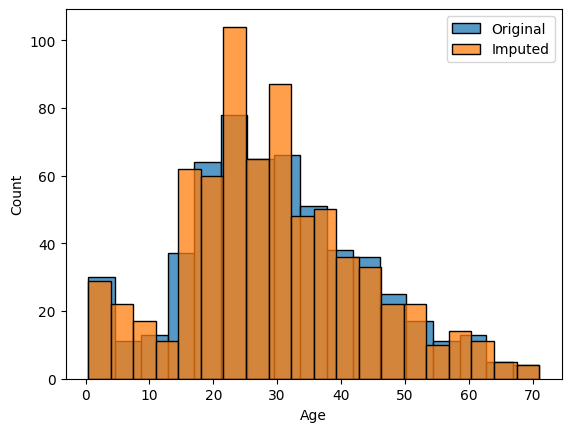

In [15]:

sns.histplot(X_train['Age'],label='Original')
sns.histplot(X_train['Age_imputed'],label = 'Imputed')

plt.legend()
plt.show()

In [16]:

print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  199.71237752808975


In [17]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,51.066802
Age,71.512440,204.349513,204.349513
Age_imputed,51.066802,204.349513,199.712378


<Axes: >

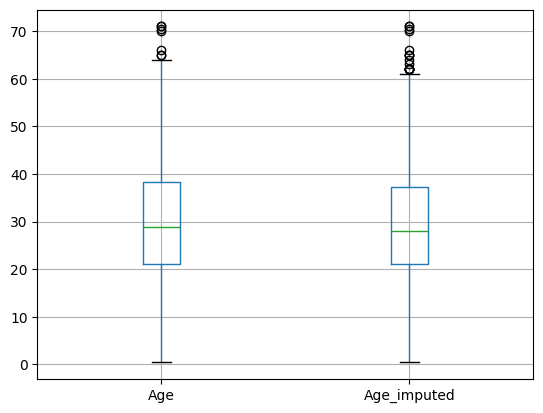

In [18]:

X_train[['Age', 'Age_imputed']].boxplot()

In [20]:
observation = X_train.iloc[0] 
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

In [21]:

data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [22]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [23]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [24]:
X = data
y = data['SalePrice']


In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [26]:

X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [27]:

X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
440,Gd,TA,555000,TA,Gd
229,TA,TA,192500,TA,TA
536,NaN,TA,188000,TA,NaN
1432,NaN,Fa,64500,Fa,NaN
1296,NaN,TA,155000,TA,NaN


In [28]:

X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values


C:\Users\Nandhini\AppData\Local\Temp\ipykernel_46952\3703099919.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['Garage

In [29]:

temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [30]:

temp

,original,imputed
TA,0.951043,0.952055
Fa,0.037171,0.035959
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [31]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp


,original,imputed
Gd,0.494272,0.644220
TA,0.412439,0.542088
Fa,0.040917,0.054994
Po,0.027823,0.037037
Ex,0.024550,0.032548


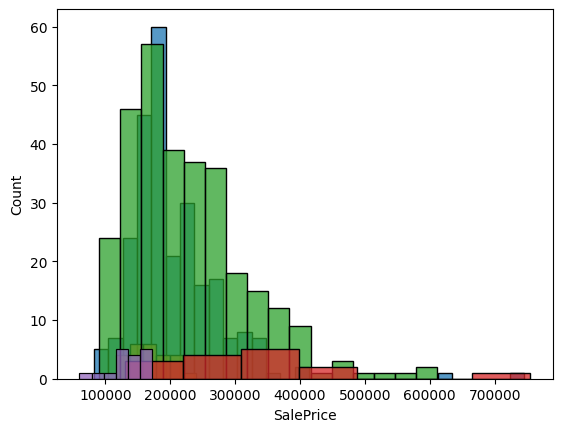

In [33]:

for category in X_train['FireplaceQu'].dropna().unique():
    sns.histplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.show()

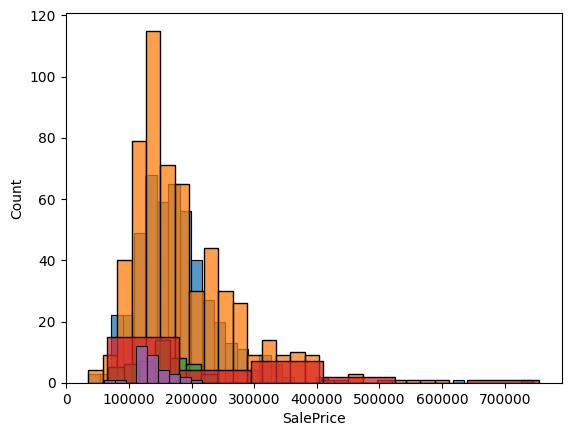

In [35]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.histplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)
plt.show()